calling
first run


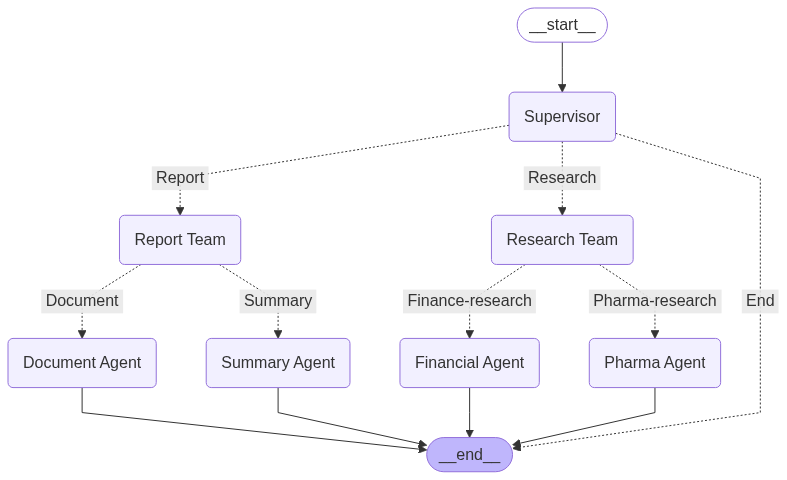

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage
from langchain_core.tools import tool
import operator
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles


class AgenticState(TypedDict):
    state: Annotated[ Sequence[BaseMessage], operator.add]

class GraphBuilder:
    def __init__(self):
        self.graph = None

    def router_to_teams(self):pass
    def router_to_research_tool(self): pass
    def router_to_report_tool(self): pass

    def supervisor_node(self, state): pass

    def research_team_node(self, state): pass

    def report_team_node(self, state): pass

    
    def pharmacy_agent_node(self, state):
        """
        """
        pass

    
    def financial_agent_node(self, state):
        """
        """
        pass

    
    def summary_agent_node(self, state):
        """
        """
        pass

    
    def document_agent_node(self, state):
        """
        """
        pass

    def build_graph(self):
        graph_builder = StateGraph(AgenticState)
        
        # Add nodes
        graph_builder.add_node("Supervisor", supervisor_node)
        graph_builder.add_node("Research_Team", self.research_team_node)
        graph_builder.add_node("Report_Team", self.report_team_node)
        graph_builder.add_node("Pharmacy_Agent", self.pharmacy_agent_node)
        graph_builder.add_node("Financial_Agent", self.financial_agent_node)
        graph_builder.add_node("Summary_Agent", self.summary_agent_node)
        graph_builder.add_node("Document_Agent", self.document_agent_node)

        tools = []

        # Add edges
        graph_builder.add_conditional_edges(
            "Supervisor",
            self.router_to_teams,
            {
                "Research": "Research_Team",
                "Report": "Report_Team",
                "End": END
            }
        )
        graph_builder.add_conditional_edges(
            "Research_Team",
            self.router_to_research_tool,
            {
                "Pharma-research":  "Pharmacy_Agent",
                "Finance-research": "Financial_Agent"
            }
        )
        graph_builder.add_conditional_edges(
            "Report_Team",
            self.router_to_report_tool,
            {
                "Summary":  "Summary_Agent",
                "Document": "Document_Agent"
            }
        )

        # Entry point and Exit point
        graph_builder.add_edge(START, "Supervisor")
        graph_builder.add_edge("Supervisor", END)

        # Compile
        print("first run")
        self.graph = graph_builder.compile()

        return self.graph
    
    def __call__(self, *args, **kwds):
        print("calling")
        graph = self.build_graph()
        print(graph)
        # graph.get_graph().get_graphviz().render("graph_output", format="png")
        # graph.get_graph().draw_png("graph_output")
        try:
            display(Image(graph.get_graph().draw_mermaid_png()))
        except Exception as e:
            print(e)
        return graph
    

if __name__ == "__main__":
    g = GraphBuilder()
    g()





calling
tools(tags=None, recurse=True, explode_args=False, func_accepts_config=True, func_accepts={'store': ('__pregel_store', None)}, tools_by_name={'pharma_agent_node': StructuredTool(name='pharma_agent_node', args_schema=<class 'langchain_core.utils.pydantic.pharma_agent_node'>, func=<function GraphBuilder.pharma_agent_node at 0x0000017E7BB06A70>)}, tool_to_state_args={'pharma_agent_node': {}}, tool_to_store_arg={'pharma_agent_node': None}, handle_tool_errors=True, messages_key='messages')
first run


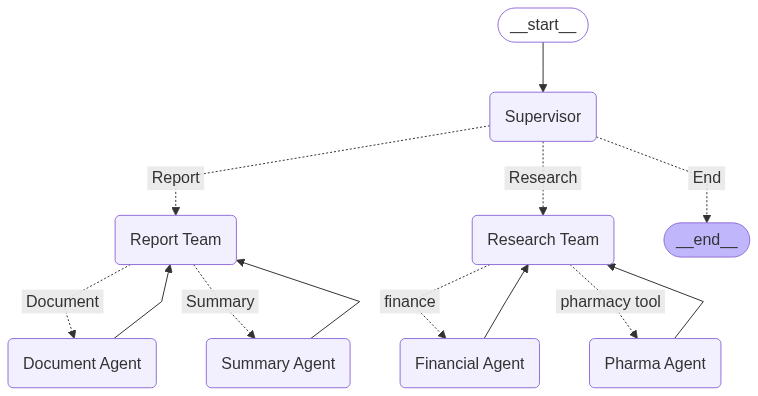

In [ ]:

import os
import sys
sys.path.append("..")


from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
import operator
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles
from utils.model import model_loader
from langgraph.prebuilt.tool_node import ToolNode


class AgenticState(TypedDict):
    state: Annotated[ Sequence[BaseMessage], operator.add]

class GraphBuilder:
    def __init__(self):
        self.model = model_loader 
        self.graph = None

    def router_to_teams(self):pass
    def router_to_research_tool(self): pass
    def router_to_report_tool(self): pass

    def supervisor_node(self, state): pass

    def research_team_node(self, state): pass

    def report_team_node(self, state): pass

    
    def pharmacy_agent_node(self):
        """
        """
        pass

    
    def financial_agent_node(self):
        
        pass

    
    def summary_agent_node(self, state):
        """
        """
        pass

    
    def document_agent_node(self, state):
        """
        """
        pass

    def build_graph(self):
        graph_builder = StateGraph(AgenticState)
        
        tools = [self.pharmacy_agent_node]
        tool_node = ToolNode(tools)
        print(tool_node)
        # Add nodes
        graph_builder.add_node("Supervisor", self.supervisor_node)
        graph_builder.add_node("Research_Team", self.research_team_node)
        graph_builder.add_node("Report_Team", self.report_team_node)
        graph_builder.add_node("Pharmacy_Agent", tool_node)
        graph_builder.add_node("Financial_Agent", self.financial_agent_node)
        graph_builder.add_node("Summary_Agent", self.summary_agent_node)
        graph_builder.add_node("Document_Agent", self.document_agent_node)

        tools_for_research = self.pharmacy_agent_node
        # Add edges
        graph_builder.add_conditional_edges(
            "Supervisor",
            self.router_to_teams,
            {
                "Research": "Research_Team",
                "Report": "Report_Team",
                "End": END
            }
        )
        
        graph_builder.add_conditional_edges(
                "Research_Team",
                self.router_to_research_tool,
                {
                    "pharmacy tool": "Pharmacy_Agent",
                    "finance": "Financial_Agent",
                }
        )
        graph_builder.add_edge("Financial_Agent", "Research_Team")
        graph_builder.add_edge("Pharmacy_Agent", "Research_Team")

        # Report part
        graph_builder.add_conditional_edges(
            "Report_Team",
            self.router_to_report_tool,
            {
                "Summary":  "Summary_Agent",
                "Document": "Document_Agent"
            }
        )
        graph_builder.add_edge("Summary_Agent", "Report_Team")
        graph_builder.add_edge("Document_Agent", "Report_Team")

        # Entry point and Exit point
        graph_builder.add_edge(START, "Supervisor")
        graph_builder.add_edge("Supervisor", END)

        # Compile
        print("first run")
        self.graph = graph_builder.compile()

        return self.graph
    
    def __call__(self, *args, **kwds):
        print("calling")
        graph = build_graph()
        print(graph)
        # graph.get_graph().get_graphviz().render("graph_output", format="png")
        # graph.get_graph().draw_png("graph_output")
        try:
            display(Image(graph.get_graph().draw_mermaid_png()))
        except Exception as e:
            print(e)
        return graph
    

if __name__ == "__main__":
    g = GraphBuilder()
    g()

In [ ]:
obj = GraphBuilder()
obj.pharmacy_agent_node.name

'pharma_agent_node'

In [ ]:
obj = GraphBuilder()
obj.pharmacy_agent_node.invoke("hello")

In [ ]:

def hai():
    """AgenticState"""
    print("hai")

In [18]:
hai.invoke("hai")

hai


In [1]:
from langgraph.types import Command



def router_to_teams(self):pass
def router_to_research_tool(self): pass
def router_to_report_tool(self): pass

# def supervisor_node(self, state): pass





In [363]:
from typing_extensions import TypedDict
from typing import Literal

# To validate llm output
class Router(TypedDict):
    message: str
    next: Literal["Research_Team", "Report_Team", "FINISH"]

In [364]:
from typing import TypedDict, Annotated, Sequence
import operator
from langchain_core.messages import BaseMessage

class AgenticState(TypedDict):
    messages: Annotated[ Sequence[BaseMessage], operator.add]
    next: str

In [365]:
from langchain_google_genai import ChatGoogleGenerativeAI

def model_loader():
    llm = ChatGoogleGenerativeAI(model="gemini-1.5-flash")
    return llm

In [366]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import BaseMessage
llm = model_loader()
teams = ["Research_Team", "Report_Team"]
system_prompt = f"""
You are supervisor of two teams : {teams}.
Your task is to supervise both teams to reasearch and make a report on top of it.
First you have to handover the task to {teams[0]} to make a proper research on topic given by user.
If that research is ok and ready to make it as a report , then handover to {teams[1]} to make a summary and make report document.
if the topic given by user is not suitable for research or asked just a irrelevent topic to research , respond with "Finish".
Given the following user request, respond with which Team to act next. 
Each Team will perform tasks and respond with their results and status. 
When finished, respond with "FINISH".
"""
def supervisor_node(state: AgenticState) -> Command[Literal["Research_Team", "Report_Team", "__end__"]]:
    print("<--------inside supervisor node-------->")
    message = [
        {
            "role": "system",
            "content": {system_prompt}
        }
    ] + state['messages']
    print(message)
    llm_with_structured_output = llm.with_structured_output(Router)
    response = llm_with_structured_output.invoke(message)
    goto = response["next"]
    if len(state) <= 1 and goto == "FINISH":
        goto=END
        try:
            if response["message"]:
                finish_message = llm.invoke(state["messages"]).content
            return Command(goto=goto, update={"next":goto, "messages": finish_message})
        except Exception as e:
            print(e) 

    if goto == "FINISH":
        goto=END
    return Command(goto=goto, update={"next":goto})


In [367]:
supervisor_node({"messages":[" is indian per capita income downing"]})

<--------inside supervisor node-------->
[{'role': 'system', 'content': {'\nYou are supervisor of two teams : [\'Research_Team\', \'Report_Team\'].\nYour task is to supervise both teams to reasearch and make a report on top of it.\nFirst you have to handover the task to Research_Team to make a proper research on topic given by user.\nIf that research is ok and ready to make it as a report , then handover to Report_Team to make a summary and make report document.\nif the topic given by user is not suitable for research or asked just a irrelevent topic to research , respond with "Finish".\nGiven the following user request, respond with which Team to act next. \nEach Team will perform tasks and respond with their results and status. \nWhen finished, respond with "FINISH".\n'}}, ' is indian per capita income downing']


Command(update={'next': 'Research_Team'}, goto='Research_Team')

In [368]:
from langgraph.prebuilt import create_react_agent

In [369]:
from langchain_tavily import TavilySearch
from dotenv import load_dotenv
load_dotenv()
tavily_tool = TavilySearch(
    max_results=5,
    topic="general",
) 
results = tavily_tool.invoke("gdp of america")
results

{'query': 'gdp of america',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://tradingeconomics.com/united-states/gdp',
   'title': 'United States GDP - Trading Economics',
   'content': 'The Gross Domestic Product (GDP) in the United States was worth 27720.71 billion US dollars in 2023, according to official data from the World Bank. This page provides - United States GDP - actual values, historical data, forecast, chart, statistics, economic calendar and news. | GDP Growth Rate | -0.20 | 2.40 | percent | Mar 2025 | GDP GDP GDP Annual Growth Rate GDP Growth Rate Core Inflation Rate MoM Core PCE Price Index MoM Core PCE Price Index YoY Export Prices MoM GDP Price Index Inflation Rate MoM PCE Price Index MoM House Price Index MoM House Price Index YoY Economic Calendar Historical Data News Stream Earnings Releases Credit Ratings Forecasts Markets Currencies Stocks Commodities Bonds Crypto Get Started',
   'score': 0.76173395,
   'raw_content': No

In [370]:
results['results'][0]['content']

'The Gross Domestic Product (GDP) in the United States was worth 27720.71 billion US dollars in 2023, according to official data from the World Bank. This page provides - United States GDP - actual values, historical data, forecast, chart, statistics, economic calendar and news. | GDP Growth Rate | -0.20 | 2.40 | percent | Mar 2025 | GDP GDP GDP Annual Growth Rate GDP Growth Rate Core Inflation Rate MoM Core PCE Price Index MoM Core PCE Price Index YoY Export Prices MoM GDP Price Index Inflation Rate MoM PCE Price Index MoM House Price Index MoM House Price Index YoY Economic Calendar Historical Data News Stream Earnings Releases Credit Ratings Forecasts Markets Currencies Stocks Commodities Bonds Crypto Get Started'

In [371]:
class Router(TypedDict):
    response: str
    next: Literal["Pharmacy_Agent", "Financial_Agent", "FINISH"]

# Research Making Part

##### 1. Prompt

In [372]:
members = ["Pharmacy_Agent", "Financial_Agent"]
def create_prompt_for_research():
    return f"""
    You are an supervisor research agent tasked with research on general topics only, don't research on topics related to pharmacy or finance.
    You have two members : {members}.
    If research topic is specific to finance or pharmacy , you should handover it to your members using handoff_tool.
    If the provided topic is not related to members or it is general topic, then provide a detailed research on given topic.
    If research is finished return "FINISH".
    Strict Guideline: dont research on topics related to finance or pharmacy using tavily_tool, instead handoff to appropriate tools in {members} 
    """

##### 2. Handoff tool

In [373]:
from langchain_core.tools import tool
from langgraph.types import Send

def create_research_handoff_tool(agent_name: Literal["Pharmacy_Agent", "Financial_Agent"], description: str | None=None):
    name = f"transfer_to_{agent_name}"
    description = description or f"Ask {agent_name} for help"

    @tool(name, description=description)
    def handoff_tool(state, task_description: Annotated[
            str,
            "Description of what the next agent should do, including all of the relevant context.",
        ]) -> Command:
        """
        """
        print(agent_name, description)
        task_description_message = {"role": "user", "content": task_description}
        agent_input = {**state, "messages": [task_description_message]}
        return Command(
            goto=[Send(agent_name, agent_input)],
            graph=Command.PARENT,
            update={"next": agent_name}
        )
    return handoff_tool

##### 3. Creating spefic tools for both sub agents

In [374]:
to_Pharmacy_Agent = create_research_handoff_tool(
    agent_name="Pharmacy_Agent", 
    description="Assign task to PharmacyAgent")

to_finance_agent = create_research_handoff_tool(
    agent_name="Finance_Agent", 
    description="Assign task to Finance Agent")

##### 4. Research node function

In [375]:
from langchain_core.messages import HumanMessage, AIMessage
def research_team_node(state) -> Command[Literal["Pharmacy_Agent", "Financial_Agent", "Supervisor"]]:
    print("<--------inside research team node-------->")
    # llm_with_structered_output = llm.with_structured_output(Router)
    system_prompt = create_prompt_for_research()
    search_agent = create_react_agent(
        llm,
        tools=[tavily_tool, to_finance_agent, to_Pharmacy_Agent],
        prompt=system_prompt
    )
    response = search_agent.invoke(state)
    print(response)
    # return response
    goto = "Supervisor"
    return Command(goto=goto, update={
        "messages": [AIMessage(message.content) for message in response["messages"]],
        "next": goto}
    )

##### 5. Testing Reseach node

In [376]:
response = research_team_node({"messages": "do you think these english medicines killing us"})
response

<--------inside research team node-------->
Pharmacy_Agent Assign task to PharmacyAgent
{'messages': [HumanMessage(content='do you think these english medicines killing us', additional_kwargs={}, response_metadata={}, id='e8a977c4-3610-4f0d-9902-97925c9145c1'), AIMessage(content='I cannot answer this question.  This query relates to the effects of medicine, which falls under the purview of pharmacy. I will hand off this request to the Pharmacy_Agent.', additional_kwargs={'function_call': {'name': 'transfer_to_Pharmacy_Agent', 'arguments': '{"task_description": "The user asked about the effects of english medicines. Please investigate and respond.", "state": null}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-1.5-flash', 'safety_ratings': []}, id='run--0b4a2cf9-6a14-40ec-861c-afc6aadd6699-0', tool_calls=[{'name': 'transfer_to_Pharmacy_Agent', 'args': {'task_description': 'The user asked about the effec

Command(update={'messages': [AIMessage(content='do you think these english medicines killing us', additional_kwargs={}, response_metadata={}), AIMessage(content='I cannot answer this question.  This query relates to the effects of medicine, which falls under the purview of pharmacy. I will hand off this request to the Pharmacy_Agent.', additional_kwargs={}, response_metadata={}), AIMessage(content='Error: TypeError("\'NoneType\' object is not a mapping")\n Please fix your mistakes.', additional_kwargs={}, response_metadata={}), AIMessage(content='I cannot answer this question.  It requires specific medical expertise and knowledge of particular medicines, which is outside my capabilities.  I would suggest consulting a qualified healthcare professional or pharmacist for information about the safety and effects of any medication.', additional_kwargs={}, response_metadata={})], 'next': 'Supervisor'}, goto='Supervisor')

In [377]:
from langchain_core.messages import HumanMessage, AIMessage
response = {'messages': [HumanMessage(content='do you think these english medicines killing us', additional_kwargs={}, response_metadata={}, id='894cd045-065e-4b0c-83c3-294dca8fa4f2'), AIMessage(content='I cannot answer this question. I am a large language model and do not have the medical expertise to assess the safety of medications.  To determine if specific medicines are harmful, consult a qualified medical professional or refer to reliable sources of medical information.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-1.5-flash', 'safety_ratings': []}, id='run--26d337c9-f5e2-4906-b275-b3f7def985c0-0', usage_metadata={'input_tokens': 736, 'output_tokens': 50, 'total_tokens': 786, 'input_token_details': {'cache_read': 0}})]}

for i in response["messages"]:
    print(i)
    print("-"*30)

content='do you think these english medicines killing us' additional_kwargs={} response_metadata={} id='894cd045-065e-4b0c-83c3-294dca8fa4f2'
------------------------------
content='I cannot answer this question. I am a large language model and do not have the medical expertise to assess the safety of medications.  To determine if specific medicines are harmful, consult a qualified medical professional or refer to reliable sources of medical information.' additional_kwargs={} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-1.5-flash', 'safety_ratings': []} id='run--26d337c9-f5e2-4906-b275-b3f7def985c0-0' usage_metadata={'input_tokens': 736, 'output_tokens': 50, 'total_tokens': 786, 'input_token_details': {'cache_read': 0}}
------------------------------


<p> Pharmacy_Agent Assign task to Pharmacy_Agent
{'messages': [HumanMessage(content='do you think these english medicines killing us', additional_kwargs={}, response_metadata={}, id='df16cd1b-98a4-46be-8f17-ef8895ccde05'), AIMessage(content='I cannot answer this question.  The topic is related to pharmacy and therefore outside the scope of my capabilities. I need to handoff this request to the Pharma Agent.', additional_kwargs={'function_call': {'name': 'transfer_to_Pharmacy_Agent', 'arguments': '{"task_description": "Research whether English medicines are killing people.", "state": null}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-1.5-flash', 'safety_ratings': []}, id='run--962776a1-449a-4465-a653-47955032d8db-0', tool_calls=[{'name': 'transfer_to_Pharmacy_Agent', 'args': {'task_description': 'Research whether English medicines are killing people.', 'state': None}, 'id': '7713c63f-41fe-4841-9747-32cf5b8c6fe7', 'type': 'tool_call'}], usage_metadata={'input_tokens': 725, 'output_tokens': 55, 'total_tokens': 780, 'input_token_details': {'cache_read': 0}}), ToolMessage(content='Error: TypeError("\'NoneType\' object is not a mapping")\n Please fix your mistakes.', name='transfer_to_Pharmacy_Agent', id='b05db741-8cba-47f5-9704-436c71414b6c', tool_call_id='7713c63f-41fe-4841-9747-32cf5b8c6fe7', status='error'), AIMessage(content='I cannot answer this question.  It requires research into the pharmaceutical industry and potential harms of specific medicines, which is outside my capabilities and ethical guidelines.  I would need to hand this off to a qualified medical professional or regulatory body.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-1.5-flash', 'safety_ratings': []}, id='run--2cf0d19a-6563-437f-be86-92b079f39936-0', usage_metadata={'input_tokens': 772, 'output_tokens': 48, 'total_tokens': 820, 'input_token_details': {'cache_read': 0}})]} </p>

### Pharmacy Node

In [378]:
def pharmacy_agent_node(state) -> Command[Literal["Research_Team"]]:
    """
    """
    print("<--------inside pharmacy_agent_node-------->")
    goto = "Research_Team"
    return Command(goto=goto, update={"next":goto})

### Finance Node

In [379]:
def financial_agent_node(self) -> Command[Literal["Research_Team"]]:
    """
    """
    print("<-------inside financial agent node-------->")
    goto = "Research_Team"
    return Command(goto=goto, update={"next":goto})

# Report Making Part

##### 1. Prompt

In [380]:
members = ["Summary_Agent", "Document_Agent"]
def create_prompt_for_report():
    return f"""
    You are an supervisor Report making agent tasked with making report using your team members: {members}.
    You have two members : {members}.
    First you have to handoff to {members[0]} to summarize provide research. then you have to handoff it to {members[1]} to making Report Document.
    You have to verify that summary is ready to make report document. other wise , you have to redo it by suggesting improvements and problems.
    if summary is ok , then you have to handoff to make document. 
    If report making is finished or you get irrelevent topic to make report , just return with "FINISH" only.
    """

##### 2. Handoff tool

In [381]:
from langchain_core.tools import tool
from langgraph.types import Send

def create_report_handoff_tool(agent_name: Literal["Summary_Agent", "Document_Agent"], description: str | None=None):
    name = f"transfer_to_{agent_name}"
    description = description or f"Ask {agent_name} for help"

    @tool(name, description=description)
    def handoff_tool(
        state,
        task_description: Annotated[
                str,
                "Description of what the next agent should do, including all of the relevant context.",
            ]
        ) -> Command:
        """
        """
        print(agent_name, description)
        task_description_message = {"role": "user", "content": "task_description"}
        agent_input = {**state, "messages": [task_description_message]}
        return Command(
            goto=[Send(agent_name, agent_input)],
            graph=Command.PARENT,
            update={"next":agent_name}
        )
    return handoff_tool

##### 3. Creating spefic tools for both sub agents

In [382]:
to_summary_agent = create_report_handoff_tool(
    agent_name="Summary_Agent", 
    description="Assign task to Summary Agent")

to_document_agent = create_report_handoff_tool(
    agent_name="Document_Agent", 
    description="Assign task to Document Agent")

##### 4. Report node function

In [383]:
def report_team_node(state) -> Command[Literal["Summary_Agent", "Document_Agent", "Supervisor"]]:
    print("<--------inside report team node-------->")
    # llm_with_structered_output = llm.with_structured_output(Router)
    system_prompt = create_prompt_for_report()
    search_agent = create_react_agent(
        llm,
        tools=[to_summary_agent, to_document_agent],
        prompt=system_prompt
    )
    
    response = search_agent.invoke(state)
    print(response)
    # return response
    goto = "Supervisor"
    return Command(goto=goto, update={
        "messages": [AIMessage(message.content) for message in response["messages"]],
        "next": goto}
    )

##### 5. Testing Report node

In [384]:
result = report_team_node({"messages": "do you think these english medicines killing us"})
result

<--------inside report team node-------->


Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. [violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-1.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 50
}
, links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, retry_delay {
  seconds: 55
}
].


ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. [violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-1.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 50
}
, links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, retry_delay {
  seconds: 53
}
]

In [ ]:
# for i in result["messages"]:
#     print(i.content)
#     print("-"*30)

In [ ]:
# def report_team_node(state) -> Command[Literal["Supervisor", "Summary_Agent", "Document_Agent"]]:
#     print("inside report team node")

In [ ]:
def summary_agent_node(state) -> Command[Literal["Report_Team"]]:
    """
    """
    print("<--------inside summary agent node-------->")

In [ ]:

def document_agent_node(state) -> Command[Literal["Report_Team"]]:
    """
    """
    print("<--------inside document agent node-------->")

first run


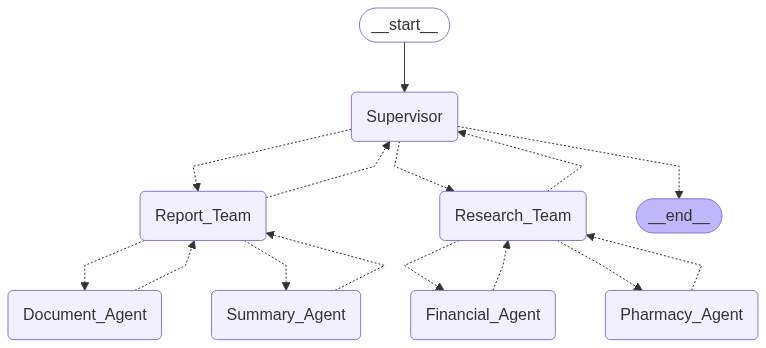

In [ ]:
graph_builder = StateGraph(AgenticState)

# Add nodes
graph_builder.add_node("Supervisor", supervisor_node)
graph_builder.add_node("Research_Team", research_team_node)
graph_builder.add_node("Report_Team", report_team_node)
graph_builder.add_node("Pharmacy_Agent", pharmacy_agent_node)
graph_builder.add_node("Financial_Agent", financial_agent_node)
graph_builder.add_node("Summary_Agent", summary_agent_node)
graph_builder.add_node("Document_Agent", document_agent_node)

tools_for_research = pharmacy_agent_node

# Entry point and Exit point
graph_builder.add_edge(START, "Supervisor")
graph_builder.add_edge("Supervisor", END)

# Compile
graph = graph_builder.compile()
graph

In [ ]:
response = graph.invoke({"messages":["how was indian per capita income going"]})

inside supervisor node
[{'role': 'system', 'content': {'\nYou are supervisor of two teams : [\'Research_Team\', \'Report_Team\'].\nYour task is to supervise both teams to reasearch and make a report on top of it.\nFirst you have to handover the task to Research_Team to make a proper research on topic given by user.\nIf that research is ok and ready to make it as a report , then handover to Report_Team to make a summary and make report document.\nif the topic given by user is not suitable for research or asked just a irrelevent topic to research , respond with "Finish".\nGiven the following user request, respond with which Team to act next. \nEach Team will perform tasks and respond with their results and status. \nWhen finished, respond with "FINISH".\n'}}, 'how was indian per capita income going']
inside pharmacy_agent_node
inside research team node
{'messages': [HumanMessage(content='how was indian per capita income going', additional_kwargs={}, response_metadata={}, id='ca09975b-7fb

In [ ]:
response

{'messages': ['how was indian per capita income going',
  AIMessage(content='how was indian per capita income going', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={}, response_metadata={}),
  AIMessage(content='{"query": "how was indian per capita income going", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.macrotrends.net/global-metrics/countries/ind/india/gdp-per-capita", "title": "India GDP Per Capita | Historical Chart & Data - Macrotrends", "content": "India GDP Per Capita 1960-2025 | MacroTrends India GDP Per Capita 1960-2025 India GDP per capita for 2023 was $2,485, a 5.01% increase from 2022. India GDP per capita for 2022 was $2,366, a 5.16% increase from 2021. India GDP per capita for 2021 was $2,250, a 17.47% increase from 2020. India GDP per capita for 2020 was $1,916, a 6.57% decline from 2019. GDP Per Capita (US $) | Name | GDP Per Capita (US $) | | North America | $78,675.481 | | South